# Topo : l'implémentation du modèle

Ce notebook présente l'implémentation du modèle de transmission culturelle (`simulation.py`, `run_grid.py`, `analysis.py`) : ce qu'elle modélise, comment elle est écrite, comment les grandes grilles de simulation sont produites et validées, et ce qu'elle donne face aux données empiriques. Les figures sont générées par les cellules ; l'analyse détaillée (tableaux, ajustements, interprétations) est dans `notebooks/results.ipynb`.

## En bref

- **Le modèle.** Une archive de classes (tags) grossit de `n_i` à `n_f` individus en `T` générations. À chaque génération, une fraction `mu` des nouveaux individus crée une **nouvelle classe** ; les autres **copient** une classe de l'archive avec une probabilité proportionnelle à `effectif^q` (`q` > 1 : conformisme, `q` < 1 : avantage aux classes rares).
- **Ce qui change par rapport au v1.** Il n'y a plus de taux d'archivage `archive_rate` ni d'ensemble de classes fixé : l'archive est cumulative et finit à `n_f` individus, et l'innovation (`mu`) crée de nouvelles classes. Les indices portent sur l'archive finale.
- **Passage à l'échelle.** Deux grilles de **5 millions de runs** (`n_f` = 10 000 et 30 901), calculées en une heure environ chacune sur 16 à 20 processus, stockées en blocs reproductibles et reprenables.
- **Résultat.** Le modèle reproduit les indices et la **forme** de la distribution empirique (exposant de loi de puissance 1,55 contre 1,53 ± 0,05) pour `q` ≈ 0,6–0,7 (avantage aux classes rares) et ≈ 180–210 classes créées. Seuls `q` et `mu` sont bien identifiables ; dès que `C` atteint quelques dizaines, les conditions initiales sont « oubliées ». Le modèle produit un peu trop de classes rares.

*Sommaire : 1. Le modèle · 2. L'implémentation · 3. Validation · 4. Résultats · 5. Limites et suite.*

In [1]:
import sys, inspect, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from scipy import stats

sys.path.insert(0, str(Path("..").resolve()))       # racine du repo : simulation, run_grid, analysis
from simulation import Simulation, EMPIRICAL_COUNTS, compute_metrics
from run_grid import load_results, load_counts
from analysis import Explorer, fit_power_law_mle, draw_fit

plt.rcParams.update({"figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3})
emp = np.array(EMPIRICAL_COUNTS)                    # comptes empiriques par catégorie (176 catégories, 30 901 occurrences)
emp_fit = fit_power_law_mle(emp)
print(f"empirique : {len(emp)} catégories, {emp.sum()} occurrences, exposant MLE {emp_fit['alpha']:.2f} ± {emp_fit['sigma']:.2f} (xmin = {emp_fit['xmin']:.0f})")

empirique : 176 catégories, 30901 occurrences, exposant MLE 1.53 ± 0.05 (xmin = 10)


## 1. Le modèle

### Principe

On suit une **archive** : l'ensemble cumulé de tous les individus (ici des occurrences de catégories) apparus depuis le début, chacun rattaché à une classe.

1. **État initial.** `n_i` individus répartis sur `C` classes selon une loi de puissance : probabilité de la classe de rang `r` proportionnelle à `r^(-alpha)` (`alpha` = 0 : uniforme).
2. **À chaque génération** `t = 1..T`, on ajoute `n_t` individus, de sorte que la taille de l'archive passe linéairement de `n_i` à `n_f` : l'archive contient exactement `n_f` individus à la fin.
   - `k ~ Binomial(n_t, mu)` individus sont des **innovateurs** : chacun crée sa propre nouvelle classe (effectif 1).
   - Les `n_t - k` autres **copient** une classe de l'archive, tirée avec une probabilité proportionnelle à `effectif(c)^q`.
   - Toute la génération est ajoutée à l'archive (les classes créées à la génération `t` ne sont copiables qu'à partir de `t+1`).
3. **Mesure.** À la fin, on calcule des indices de diversité sur les effectifs par classe de l'archive.

| Paramètre | Rôle | Plage tirée dans les grilles |
|---|---|---|
| `q` | biais de conformité : `q` > 1 favorise les classes fréquentes (conformisme), `q` < 1 les classes rares, `q` = 1 est neutre | [0,5 ; 1,5] |
| `mu` | probabilité d'innovation par individu et par génération | [0 ; 0,05] (`n_f` = 10 000) ou [0 ; 0,02] (`n_f` = 30 901) |
| `alpha` | exposant de la loi de puissance de l'état initial | [0 ; 2] |
| `C`, `n_i` | nombre de classes et taille de la population initiales | [2 ; 200], [1 ; 100] |
| `T` | nombre de générations | [300 ; 1000] |
| `n_f` | taille finale de l'archive | 10 000 ou 30 901 (= occurrences empiriques) |

Le nombre de classes créées est environ `mu × n_f` : `mu` et `n_f` jouent un rôle conjoint, d'où le rééchelonnement de `mu` entre les deux grilles.

### Un run

Un run avec les paramètres médians des meilleurs runs (plus bas) : taille de l'archive, nombre de classes et nombres de Hill au fil des générations, puis distribution rang-fréquence finale comparée à l'empirique.

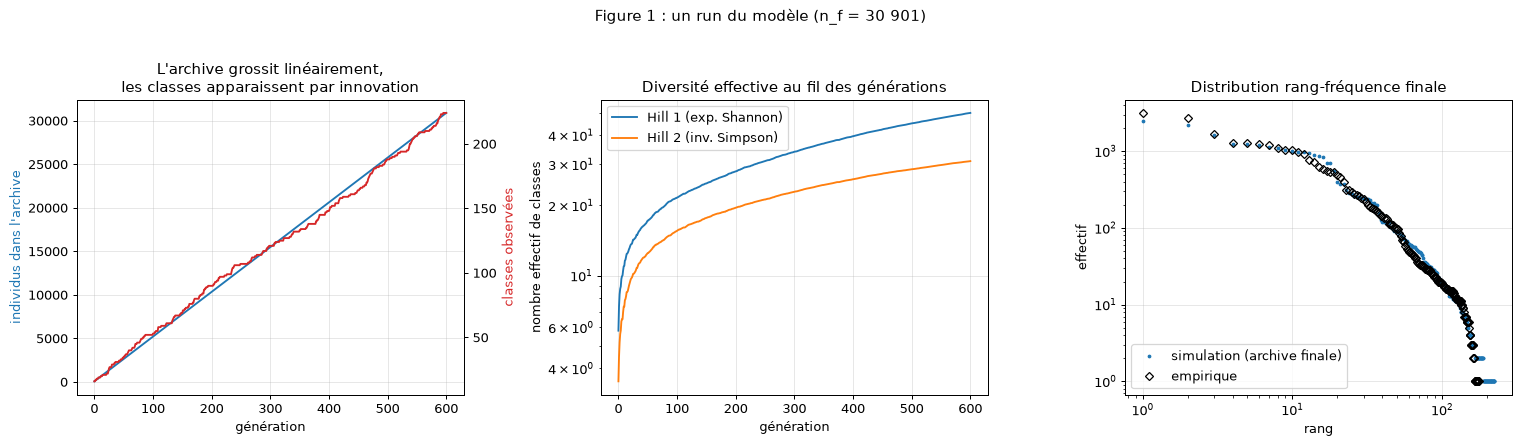

{'gini': 0.878, 'gini_obs': 0.827, 'hill_0': 224.0, 'hill_1': 49.884, 'hill_2': 30.989, 'hill_inf': 12.4, 'chao1': 253.455, 'n_classes': 224.0, 'kl_emp': 0.015}


In [2]:
P = dict(n_i=76, n_f=30_901, C=110, T=600, alpha=1.78, mu=0.0068, q=0.73)     # médianes des 1000 meilleurs runs par KL (grille 30 901)
sim = Simulation(**P, seed=1).run(track_history=True)
h = sim.history
sizes = np.rint(np.linspace(P["n_i"], P["n_f"], P["T"] + 1))                  # taille de l'archive à chaque génération

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
ax = axes[0]
ax.plot(h["t"], sizes, color="tab:blue", label="taille de l'archive")
ax.set_xlabel("génération"); ax.set_ylabel("individus dans l'archive", color="tab:blue")
ax2 = ax.twinx(); ax2.grid(False)
ax2.plot(h["t"], h["n_classes"], color="tab:red", label="classes observées"); ax2.set_ylabel("classes observées", color="tab:red")
ax.set_title("L'archive grossit linéairement,\nles classes apparaissent par innovation")

ax = axes[1]
ax.plot(h["t"], h["hill_1"], label="Hill 1 (exp. Shannon)"); ax.plot(h["t"], h["hill_2"], label="Hill 2 (inv. Simpson)")
ax.set_yscale("log"); ax.set_xlabel("génération"); ax.set_ylabel("nombre effectif de classes"); ax.legend()
ax.set_title("Diversité effective au fil des générations")

ax = axes[2]
c = np.sort(sim.archive)[::-1]; c = c[c > 0]
ax.loglog(np.arange(1, len(c) + 1), c, ".", ms=4, label="simulation (archive finale)")
ax.loglog(np.arange(1, len(emp) + 1), emp, "D", ms=4, mfc="none", color="black", label="empirique")
ax.set_xlabel("rang"); ax.set_ylabel("effectif"); ax.set_title("Distribution rang-fréquence finale"); ax.legend()
fig.suptitle("Figure 1 : un run du modèle (n_f = 30 901)", y=1.02); fig.tight_layout(); plt.show()
print({k: round(float(v), 3) for k, v in sim.metrics.items()})

### Effet des paramètres

On fait varier un paramètre à la fois autour du jeu précédent (médiane de 5 graines par courbe). Les courbes sont comparées à l'empirique (losanges).

- **`q`** change la **forme** : `q` = 1 (neutre) et `q` > 1 (conformisme) donnent une distribution très concentrée (peu de classes dominent), `q` < 1 l'aplatit.
- **`mu`** change le **nombre de classes** (la longueur de la queue) plus que la tête.
- **Les conditions initiales** (`n_i`, `C`) n'ont presque aucun effet dès que `C` atteint quelques dizaines (courbes grise et jaune confondues) ; avec très peu de classes initiales (`C` = 10, `n_i` = 1), la tête de la distribution est plus haute : le modèle les « oublie » sauf dans ce cas extrême.

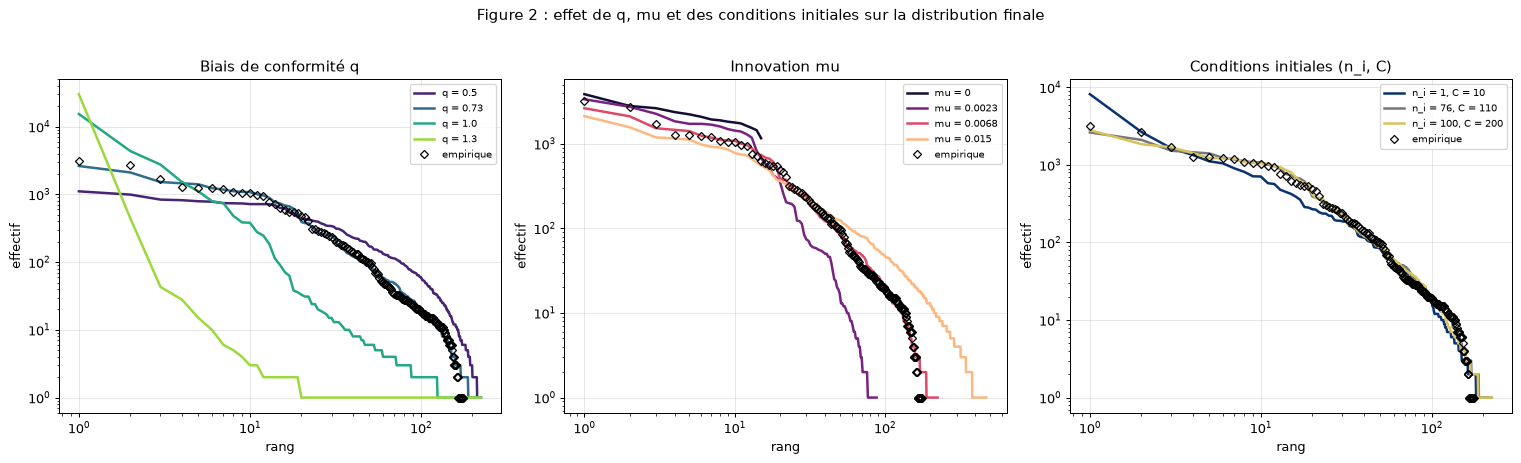

In [3]:
def median_curve(params, seeds=range(5)):
    '''Courbe rang-fréquence médiane (rang par rang) sur plusieurs graines.'''
    cs = [np.sort(Simulation(**params, seed=s).run().archive)[::-1] for s in seeds]
    padded = np.zeros((len(cs), max(len(c) for c in cs)))
    for i, c in enumerate(cs):
        padded[i, :len(c)] = c
    m = np.median(padded, axis=0)
    return m[m > 0]

def panel(ax, variants, title, cmap="viridis"):
    colors = plt.get_cmap(cmap)(np.linspace(0.1, 0.85, len(variants)))
    for color, (label, params) in zip(colors, variants):
        m = median_curve(params)
        ax.loglog(np.arange(1, len(m) + 1), m, color=color, lw=2, label=label)
    ax.loglog(np.arange(1, len(emp) + 1), emp, "D", ms=4, mfc="none", color="black", label="empirique")
    ax.set_xlabel("rang"); ax.set_ylabel("effectif"); ax.set_title(title); ax.legend(fontsize=8)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
panel(axes[0], [(f"q = {q}", {**P, "q": q}) for q in (0.5, 0.73, 1.0, 1.3)], "Biais de conformité q")
panel(axes[1], [(f"mu = {mu:g}", {**P, "mu": mu}) for mu in (0.0, 0.0023, 0.0068, 0.015)], "Innovation mu", cmap="magma")
panel(axes[2], [("n_i = 1, C = 10", {**P, "n_i": 1, "C": 10}), ("n_i = 76, C = 110", P), ("n_i = 100, C = 200", {**P, "n_i": 100, "C": 200})],
      "Conditions initiales (n_i, C)", cmap="cividis")
fig.suptitle("Figure 2 : effet de q, mu et des conditions initiales sur la distribution finale", y=1.02); fig.tight_layout(); plt.show()

## 2. L'implémentation

### Fichiers

| Fichier | Contenu |
|---|---|
| `simulation.py` | classe `Simulation` (le modèle), indices de diversité (`gini`, Hill, Chao1, `kl_divergence`), `compute_metrics`, tirage des paramètres (`draw_params`), CLI (simulation unique avec `--plot`, table de simulations avec `--n_jobs`) |
| `run_grid.py` | exécution de grosses grilles par blocs, reprise automatique, garde-fou de configuration, relecture (`load_results`, `load_counts`), mise à jour des blocs (`--upgrade`) |
| `analysis.py` | classe `Explorer` (pair plot, détail d'un indice, sélection des meilleurs runs) et ajustement MLE de loi de puissance |
| `scripts/benchmark.py` | mesure du passage à l'échelle selon le nombre de processus |

### Le cœur : `Simulation.run`

L'archive est un **vecteur d'effectifs par classe**, pas une liste d'individus : une génération coûte un tirage multinomial sur les classes existantes, soit un coût en `T × nombre de classes` indépendant du nombre d'individus.

In [4]:
print(inspect.getsource(Simulation.run))

    def run(self, track_history=False):
        """
        Exécute la simulation ; remplit `archive`, `metrics` (et `history` si demandé).

        Paramètre :
        - track_history : si True, enregistre gini / hill_1 / hill_2 / n_classes de l'archive à
                          chaque génération (coût : un tri de l'archive par génération, à réserver
                          aux runs individuels, pas aux sweeps massifs).

        Retour : self (permet `Simulation(...).run()`).
        """
        rng = np.random.default_rng(self.seed)
        C, T = self.C, self.T

        # On fixe la répartition initiale des C classes :
        ranks = np.arange(1, C + 1, dtype=float)
        probs_class = ranks ** -self.alpha
        probs_class /= probs_class.sum()

        # Tailles de génération : l'archive passe linéairement de n_i à n_f (n_f exactement à la fin)
        if self.n_f < self.n_i:
            raise ValueError(f"n_f ({self.n_f}) doit être >= n_i ({self.n_i})")
        n_t = np.d

Points de conception :
- **Tailles de génération par cumul d'arrondis** : `n_t = diff(round(linspace(n_i, n_f, T+1)))`, donc l'archive finit à exactement `n_f`.
- **Innovateurs ajoutés après le tirage des copieurs** : une classe créée à la génération `t` n'est pas copiable à `t`.
- **Reproductibilité** : un générateur `numpy.random.default_rng(seed)` par run ; les paramètres tirés (`alpha`, `mu`, `q`) sont stockés en float64 exact, car la simulation est très sensible au dernier chiffre.

### Indices calculés sur l'archive finale

`gini_obs` (Gini sur les classes observées ; à préférer à `gini`, gonflé par les classes initiales jamais échantillonnées), nombres de Hill d'ordre 0, 1, 2 et ∞, `chao1` (richesse estimée), `n_classes`, et `kl_emp` : divergence de Kullback-Leibler entre la distribution rang-fréquence **empirique** et celle de la simulation (comparaison par rang ; plancher de 0,5 occurrence pour les rangs non atteints ; la masse au-delà du rang 176 est pénalisée).

### Production d'une grille

`run_grid.py` découpe une grille en **blocs** de 5 000 runs. Chaque bloc tire lui-même ses paramètres (générateur seedé par `(rng_seed, numéro_de_bloc)`), exécute ses simulations et écrit un fichier `.npz` de façon atomique. Rien ne remonte au processus principal, ce qui permet la **parallélisation** sur `n_jobs` processus, la **reprise** après interruption (un bloc terminé est sauté) et un résultat indépendant de `n_jobs`. Un fichier `grid_config.json` mémorise les bornes : relancer avec d'autres bornes dans le même dossier est refusé.

Chaque bloc contient les paramètres exacts, les indices, et la **distribution finale de chaque run** sous forme d'histogramme des abondances (sans perte pour tous les indices, environ 100 octets par run contre environ 10 ko en vecteur dense).

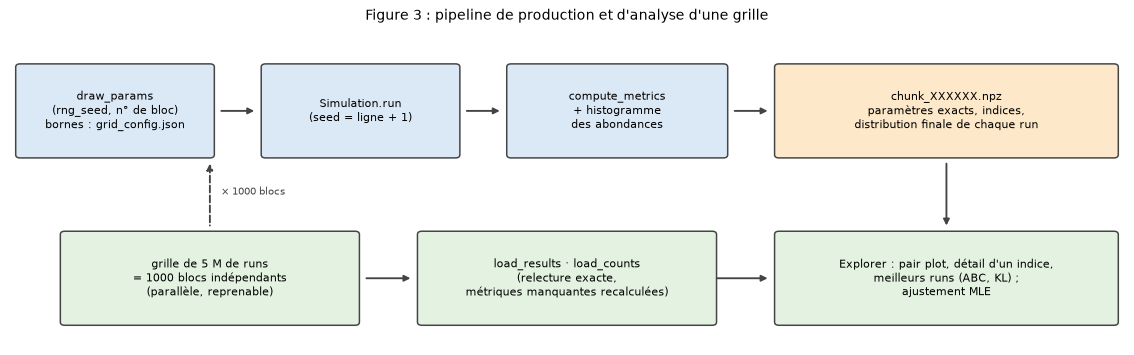

In [5]:
fig, ax = plt.subplots(figsize=(16, 4.6)); ax.axis("off"); ax.set_xlim(0, 100); ax.set_ylim(0, 40)

def box(x, y, w, h_, text, color):
    ax.add_patch(FancyBboxPatch((x, y), w, h_, boxstyle="round,pad=0.4", fc=color, ec="#444", lw=1.2))
    ax.text(x + w / 2, y + h_ / 2, text, ha="center", va="center", fontsize=9)

def arrow(x0, x1, y):
    ax.annotate("", xy=(x1, y), xytext=(x0, y), arrowprops=dict(arrowstyle="-|>", color="#444", lw=1.5))

box(1, 24, 17, 11, "draw_params\n(rng_seed, n° de bloc)\nbornes : grid_config.json", "#dbe9f6")
box(23, 24, 17, 11, "Simulation.run\n(seed = ligne + 1)", "#dbe9f6")
box(45, 24, 19, 11, "compute_metrics\n+ histogramme\ndes abondances", "#dbe9f6")
box(69, 24, 30, 11, "chunk_XXXXXX.npz\nparamètres exacts, indices,\ndistribution finale de chaque run", "#fde9c9")
arrow(18.8, 22.2, 29.5); arrow(40.8, 44.2, 29.5); arrow(64.8, 68.2, 29.5)
box(5, 3, 26, 11, "grille de 5 M de runs\n= 1000 blocs indépendants\n(parallèle, reprenable)", "#e3f2e1")
box(37, 3, 26, 11, "load_results · load_counts\n(relecture exacte,\nmétriques manquantes recalculées)", "#e3f2e1")
box(69, 3, 30, 11, "Explorer : pair plot, détail d'un indice,\nmeilleurs runs (ABC, KL) ;\najustement MLE", "#e3f2e1")
arrow(63.2, 68.2, 8.5); arrow(31.8, 36.2, 8.5)
ax.annotate("", xy=(84, 23.2), xytext=(84, 14.8), arrowprops=dict(arrowstyle="<|-", color="#444", lw=1.5))
ax.annotate("", xy=(18, 14.8), xytext=(18, 23.2), arrowprops=dict(arrowstyle="<|-", color="#444", lw=1.5, ls="--"))
ax.text(19, 19, "× 1000 blocs", fontsize=8, color="#444")
ax.set_title("Figure 3 : pipeline de production et d'analyse d'une grille", fontsize=11)
plt.show()

### Coût

| Grille | Processus | Durée | Stockage (blocs) |
|---|---|---|---|
| 5 M de runs, `n_f` = 10 000 | 16 | 60 min | ≈ 650 Mo |
| 5 M de runs, `n_f` = 30 901 | 20 | 71 min | ≈ 850 Mo |

Soit environ 12 à 17 ms de calcul par simulation (cumulé sur les processus). Le gain avec le nombre de processus plafonne : sur le CPU du serveur (8 cœurs performance avec hyperthreading + 12 cœurs efficacité), un benchmark de l'époque donnait environ ×8 à 24 processus, avec une efficacité qui tombe à 33 %.

## 3. Validation

On charge la grille `n_f = 30 901` (5 M de runs, blocs `results/grid_n30901/chunks/`, à rapatrier du serveur avec `rsync`, cf. README) et on vérifie qu'elle est cohérente.

- **Uniformité** des paramètres tirés (figure 4).
- **Propriétés** qui doivent toujours être vraies (Gini dans [0, 1], `hill_0 ≥ hill_1 ≥ hill_2 ≥ hill_inf`, `chao1 ≥ hill_0`, `kl_emp ≥ 0`…).
- **Rejeu** : relancer un run à partir de ses paramètres exacts et de sa graine redonne les mêmes indices (sauf environ 1 % des runs, lorsque la version de numpy diffère entre le serveur et la machine locale : la simulation amplifie la moindre différence d'arrondi).
- **Reproductibilité d'une grille** : les 1 000 000 premiers runs de la grille à 5 M sont identiques à ceux d'une grille de 1 M précédente (mêmes graines, mêmes bornes).

In [6]:
GRID = Path("../results/grid_n30901/chunks"); N_F = 30_901; N_SIMS = 5_000_000
t0 = time.time()
df = pd.DataFrame(load_results(GRID))
df = df.astype({"C": "int16", "n_i": "int16", "n_f": "int32", "T": "int16", "seed": "int32", "n_classes": "int16",
                "gini": "float32", "gini_obs": "float32", "hill_0": "float32", "hill_1": "float32", "hill_2": "float32",
                "hill_inf": "float32", "chao1": "float32", "kl_emp": "float32"})
assert len(df) == N_SIMS and (df["seed"].to_numpy() == np.arange(1, N_SIMS + 1)).all() and (df["n_f"] == N_F).all()
ex = Explorer(df)
print(f"{len(df):,} runs chargés en {time.time() - t0:.0f} s ; valeurs manquantes : {int(df.isna().sum().sum())}")

tol = 1 - 1e-5
checks = {
    "gini et gini_obs dans [0, 1], gini_obs <= gini": bool(df.gini.between(0, 1).all() and df.gini_obs.between(0, 1).all() and (df.gini_obs <= df.gini * (1 + 1e-5)).all()),
    "hill_0 >= hill_1 >= hill_2 >= hill_inf": bool(((df.hill_0 >= df.hill_1 * tol) & (df.hill_1 >= df.hill_2 * tol) & (df.hill_2 >= df.hill_inf * tol)).all()),
    "hill_0 == n_classes": bool((df.hill_0 == df.n_classes).all()),
    "chao1 >= hill_0": bool((df.chao1 >= df.hill_0 * tol).all()),
    "kl_emp >= 0": bool((df.kl_emp >= 0).all()),
}
for k, ok in checks.items():
    print(("OK   " if ok else "ÉCHEC"), k)

sample = df.sample(30, random_state=0); errs = []
for _, r in sample.iterrows():
    s = Simulation(int(r.n_i), int(r.n_f), int(r.C), int(r["T"]), float(r.alpha), float(r.mu), float(r.q), int(r.seed)).run()
    errs.append(max(abs(s.metrics[k] - r[k]) / max(abs(s.metrics[k]), 1e-12) for k in ["gini_obs", "hill_1", "hill_2", "hill_inf", "chao1", "kl_emp"]))
print(f"rejeu de 30 runs : {(np.array(errs) < 1e-4).sum()} / 30 reproduits à l'identique")

5,000,000 runs chargés en 5 s ; valeurs manquantes : 0
OK    gini et gini_obs dans [0, 1], gini_obs <= gini
OK    hill_0 >= hill_1 >= hill_2 >= hill_inf
OK    hill_0 == n_classes
OK    chao1 >= hill_0
OK    kl_emp >= 0


rejeu de 30 runs : 29 / 30 reproduits à l'identique


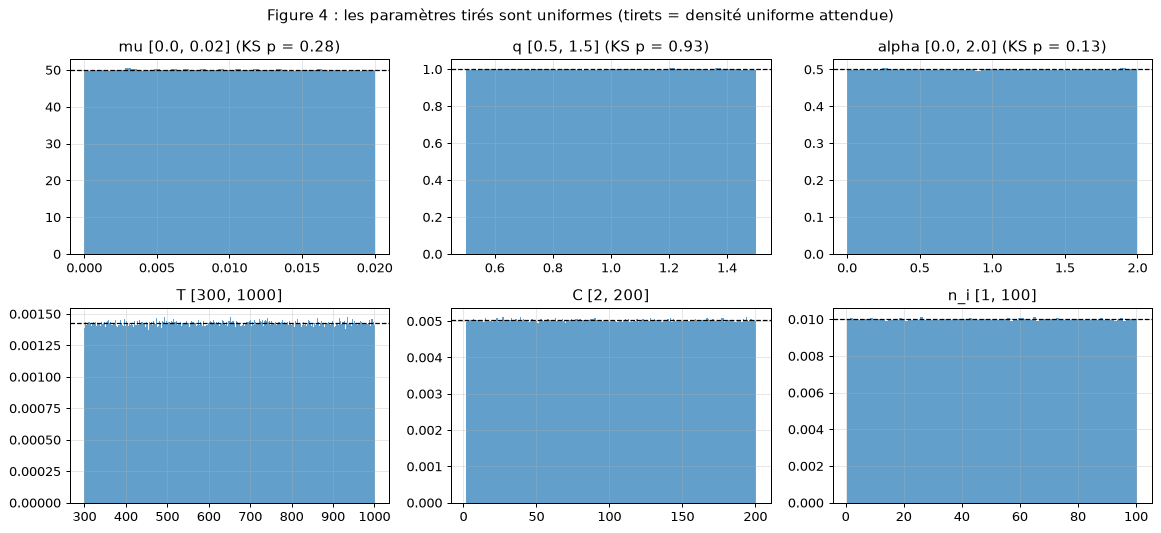

In [7]:
bounds = {"mu": (0.0, 0.02), "q": (0.5, 1.5), "alpha": (0.0, 2.0)}
int_bounds = {"T": (300, 1000), "C": (2, 200), "n_i": (1, 100)}
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, name in zip(axes.ravel(), [*bounds, *int_bounds]):
    x = df[name].to_numpy(); lo, hi = (bounds | int_bounds)[name]
    ax.hist(x, bins=np.arange(lo - 0.5, hi + 1.5) if name in int_bounds else 50, density=True, alpha=0.7)
    ax.axhline(1 / (hi - lo + (name in int_bounds)), color="k", ls="--", lw=1)
    if name in bounds:
        p = stats.kstest((np.random.default_rng(0).choice(x, size=100_000, replace=False) - lo) / (hi - lo), "uniform").pvalue
        ax.set_title(f"{name} [{lo}, {hi}] (KS p = {p:.2f})")
    else:
        ax.set_title(f"{name} [{lo}, {hi}]")
fig.suptitle("Figure 4 : les paramètres tirés sont uniformes (tirets = densité uniforme attendue)"); fig.tight_layout(); plt.show()

## 4. Résultats

### 4.1 Un piège de mesure : `gini` contre `gini_obs`

Le `gini` compte les classes initiales jamais échantillonnées (effectif 0) : elles n'existent pas dans l'empirique, où les 176 catégories sont toutes observées, et gonflent l'indice. Le `gini_obs` ne porte que sur les classes observées. La figure 5 montre l'écart ; une première sélection des meilleurs runs fondée sur `gini` avait écarté les runs qui ressemblaient le mieux à l'empirique.

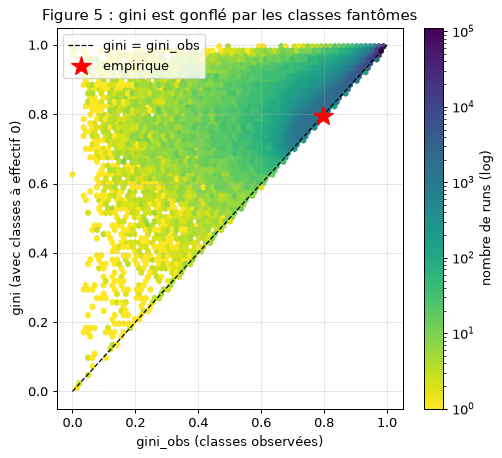

part des runs avec gini > gini_obs (au moins une classe à effectif 0) : 96%


In [8]:
s = df.sample(500_000, random_state=0)
fig, ax = plt.subplots(figsize=(6.2, 5.5))
hb = ax.hexbin(s.gini_obs, s.gini, gridsize=70, bins="log", mincnt=1, cmap="viridis_r")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="gini = gini_obs")
ax.plot(0.7963, 0.7963, "r*", ms=16, label="empirique")
ax.set_xlabel("gini_obs (classes observées)"); ax.set_ylabel("gini (avec classes à effectif 0)"); ax.legend(loc="upper left")
fig.colorbar(hb, label="nombre de runs (log)"); ax.set_title("Figure 5 : gini est gonflé par les classes fantômes"); plt.show()
print(f"part des runs avec gini > gini_obs (au moins une classe à effectif 0) : {(df.gini > df.gini_obs * (1 + 1e-5)).mean():.0%}")

### 4.2 Vue d'ensemble : paramètres → indices

Chaque point est un run (échantillon de 3 000), les lignes rouges marquent les valeurs empiriques, Hill, Chao1 et `kl_emp` sont en log10. `q` et `mu` structurent les indices ; `alpha`, `C`, `n_i` et `T` n'en ont presque aucun effet.

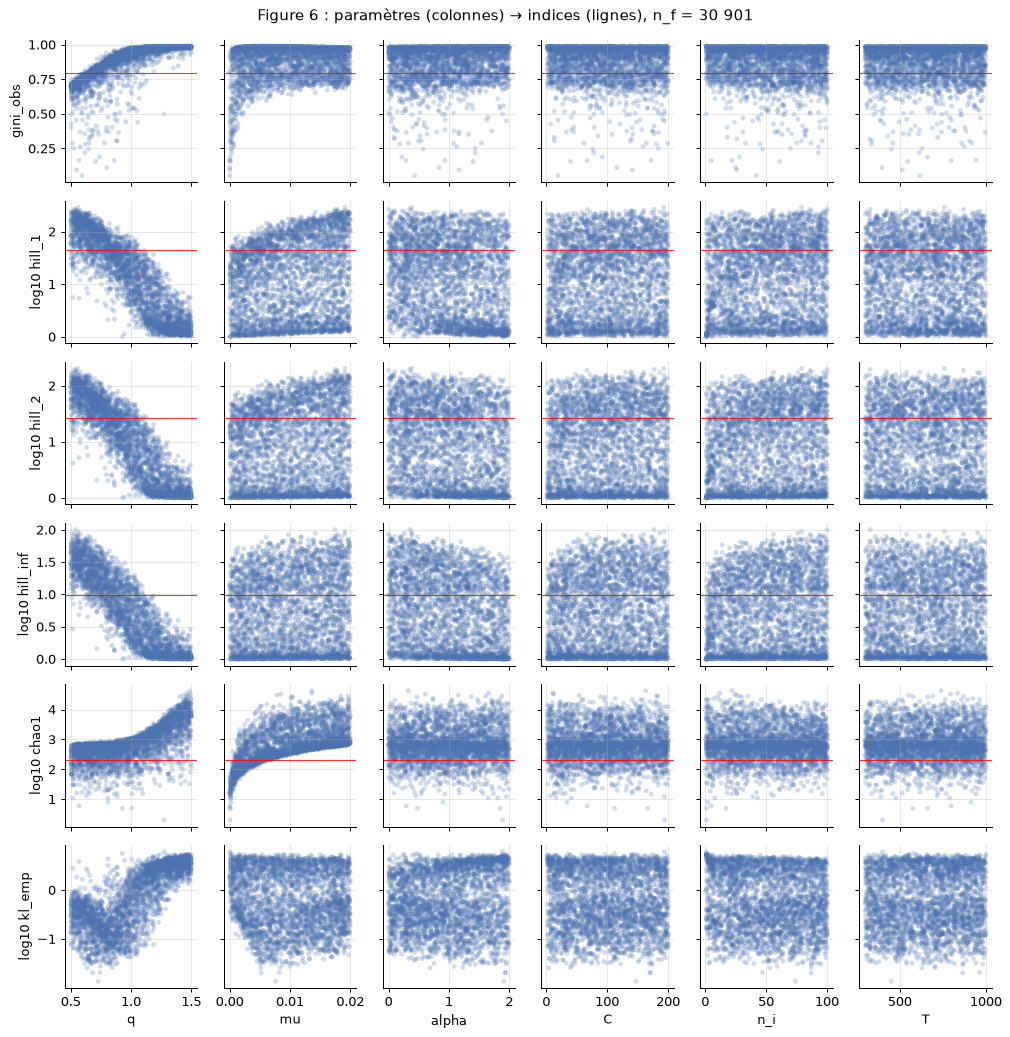

In [9]:
fig = ex.pairplot(mode="cross", vars=["q", "mu", "alpha", "C", "n_i", "T", "gini_obs", "hill_1", "hill_2", "hill_inf", "chao1", "kl_emp"])
fig.suptitle("Figure 6 : paramètres (colonnes) → indices (lignes), n_f = 30 901", y=1.01); plt.show()

### 4.3 La forme de la distribution : sélection par ABC contre par KL

Deux façons de choisir les 100 meilleurs runs :
- **ABC** : distance sur les indices scalaires `gini_obs`, `hill_1`, `hill_2`, `hill_inf`, `chao1` ;
- **KL minimal** : forme complète de la distribution rang-fréquence.

On ajuste ensuite une loi de puissance (MLE, `xmin` par minimisation KS) sur chaque run. L'archive simulée a ici la même taille que l'échantillon empirique (30 901), donc on compare directement les exposants. Les deux sélections reproduisent les indices ; seule la sélection par KL reproduit la **forme** : l'ABC plonge dans la queue.

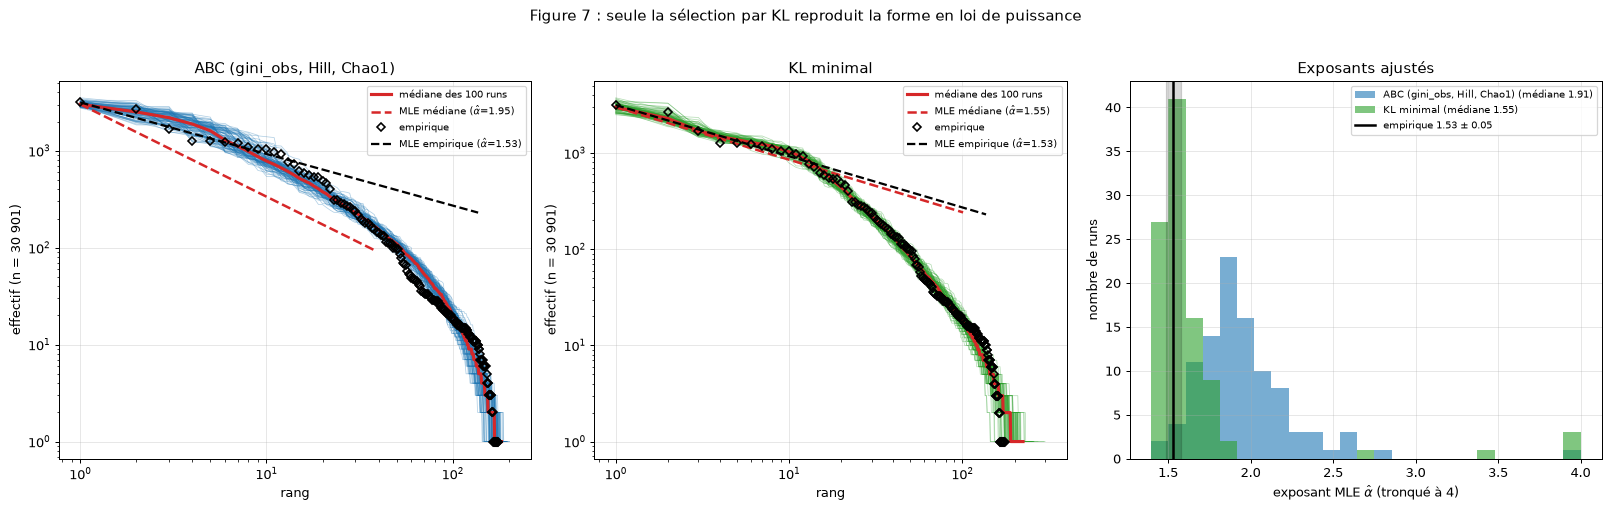

ABC (gini_obs, Hill, Chao1)    alpha médian 1.91 | n_tail médian 52 (empirique 137) | 7 / 100 à ±2σ de l'empirique
KL minimal                     alpha médian 1.55 | n_tail médian 108 (empirique 137) | 66 / 100 à ±2σ de l'empirique


In [10]:
METRICS_ABC = ("gini_obs", "hill_1", "hill_2", "hill_inf", "chao1")
sel = {"ABC (gini_obs, Hill, Chao1)": ex.closest(100, metrics=METRICS_ABC).df.sort_values("distance"),
       "KL minimal": df.nsmallest(100, "kl_emp")}
colors = {"ABC (gini_obs, Hill, Chao1)": "tab:blue", "KL minimal": "tab:green"}
counts = {k: [load_counts(GRID, int(s) - 1, 5000) for s in d["seed"]] for k, d in sel.items()}
fits = {k: pd.DataFrame([f for f in (fit_power_law_mle(c) for c in cs) if f]) for k, cs in counts.items()}

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, (name, cs) in zip(axes[:2], counts.items()):
    for c in cs:
        cp = c[c > 0]; ax.loglog(np.arange(1, len(cp) + 1), cp, color=colors[name], lw=0.6, alpha=0.35)
    padded = np.zeros((len(cs), max(len(c) for c in cs)))
    for i, c in enumerate(cs):
        padded[i, :len(c)] = c
    med = np.round(np.median(padded, axis=0)); med = med[med > 0]; mf = fit_power_law_mle(med)
    ax.loglog(np.arange(1, len(med) + 1), med, color="tab:red", lw=2.5, label="médiane des 100 runs")
    draw_fit(ax, med, mf, 1, color="tab:red", lw=2, ls="--", label=fr"MLE médiane ($\hat\alpha$={mf['alpha']:.2f})")
    ax.loglog(np.arange(1, len(emp) + 1), emp, "D", ms=5, color="black", mfc="none", mew=1.3, label="empirique")
    draw_fit(ax, emp, emp_fit, 1, color="black", lw=1.8, ls="--", label=fr"MLE empirique ($\hat\alpha$={emp_fit['alpha']:.2f})")
    ax.set_xlabel("rang"); ax.set_ylabel("effectif (n = 30 901)"); ax.set_title(name); ax.legend(fontsize=8)
ax = axes[2]
bins = np.histogram_bin_edges(np.concatenate([f.alpha.clip(upper=4) for f in fits.values()]), bins=25)
for name, f in fits.items():
    ax.hist(f.alpha.clip(upper=4), bins=bins, alpha=0.6, color=colors[name], label=f"{name} (médiane {f.alpha.median():.2f})")
ax.axvline(emp_fit["alpha"], color="black", lw=2, label=f"empirique {emp_fit['alpha']:.2f} ± {emp_fit['sigma']:.2f}")
ax.axvspan(emp_fit["alpha"] - emp_fit["sigma"], emp_fit["alpha"] + emp_fit["sigma"], color="black", alpha=0.15)
ax.set_xlabel(r"exposant MLE $\hat\alpha$ (tronqué à 4)"); ax.set_ylabel("nombre de runs"); ax.set_title("Exposants ajustés"); ax.legend(fontsize=8)
fig.suptitle("Figure 7 : seule la sélection par KL reproduit la forme en loi de puissance", y=1.02); fig.tight_layout(); plt.show()
for name, f in fits.items():
    inside = ((f.alpha - emp_fit["alpha"]).abs() <= 2 * emp_fit["sigma"]).sum()
    print(f"{name:30s} alpha médian {f.alpha.median():.2f} | n_tail médian {f.n_tail.median():.0f} (empirique {emp_fit['n_tail']}) | {inside} / 100 à ±2σ de l'empirique")

### 4.4 Quels paramètres sont identifiables ?

Pour chaque paramètre, on compare la plage occupée par les 1000 meilleurs runs (quantiles 5-95 %) à la plage tirée au départ. Une largeur proche de 0 signifie un paramètre contraint, proche de 1 un paramètre non identifiable.

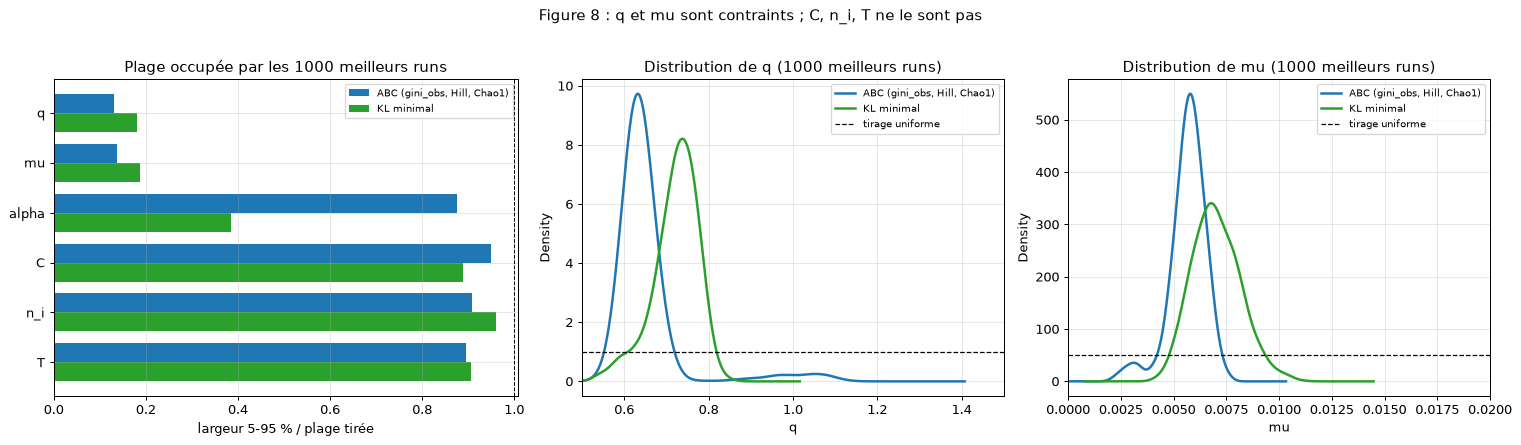

       ABC (gini_obs, Hill, Chao1)  KL minimal
q                             0.13        0.18
mu                            0.14        0.19
alpha                         0.88        0.38
C                             0.95        0.89
n_i                           0.91        0.96
T                             0.89        0.91


In [11]:
ranges = {"q": (0.5, 1.5), "mu": (0.0, 0.02), "alpha": (0.0, 2.0), "C": (2, 200), "n_i": (1, 100), "T": (300, 1000)}
tops = {"ABC (gini_obs, Hill, Chao1)": ex.closest(1000, metrics=METRICS_ABC).df, "KL minimal": df.nsmallest(1000, "kl_emp")}
width = pd.DataFrame({name: {p: (d[p].quantile(0.95) - d[p].quantile(0.05)) / (hi - lo) for p, (lo, hi) in ranges.items()} for name, d in tops.items()})

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), gridspec_kw={"width_ratios": [1.1, 1, 1]})
ax = axes[0]; y = np.arange(len(width)); hgt = 0.38
for i, name in enumerate(width.columns):
    ax.barh(y + (i - 0.5) * hgt, width[name], height=hgt, color=colors[name], label=name)
ax.set_yticks(y); ax.set_yticklabels(width.index); ax.invert_yaxis(); ax.axvline(1, color="k", lw=0.8, ls="--")
ax.set_xlabel("largeur 5-95 % / plage tirée"); ax.set_title("Plage occupée par les 1000 meilleurs runs"); ax.legend(fontsize=8, loc="upper right")
for ax, p, (lo, hi) in zip(axes[1:], ["q", "mu"], [ranges["q"], ranges["mu"]]):
    for name, d in tops.items():
        d[p].plot(kind="kde", ax=ax, color=colors[name], lw=2, label=name, bw_method=0.3)
    ax.axhline(1 / (hi - lo), color="k", ls="--", lw=1, label="tirage uniforme"); ax.set_xlim(lo, hi)
    ax.set_xlabel(p); ax.set_title(f"Distribution de {p} (1000 meilleurs runs)"); ax.legend(fontsize=8)
fig.suptitle("Figure 8 : q et mu sont contraints ; C, n_i, T ne le sont pas", y=1.02); fig.tight_layout(); plt.show()
print(width.round(2).to_string())

### 4.5 Ce qu'on retient

| | Meilleurs runs par KL (grille `n_f` = 30 901) |
|---|---|
| `q` | ≈ 0,73 (90 % entre 0,61 et 0,79) : **avantage aux classes rares**, le conformisme est exclu |
| `mu` | ≈ 0,0069, soit ≈ 210 classes créées (`mu × n_f`) ; ≈ 167 pour `n_f` = 10 000 |
| `alpha` | ≈ 1,8, mais contre la borne haute de 2,0 (tronqué) |
| `C`, `n_i`, `T` | non identifiables (89 à 96 % de la plage tirée ; seules les valeurs de `C` < 16 sont écartées) |
| exposant de loi de puissance | 1,55 (empirique 1,53 ± 0,05) ; 66 runs sur 100 compatibles (contre 7 pour la sélection ABC) |
| écart restant | `hill_0` ≈ 224 et Chao1 ≈ 256 (contre 176 et 200), 34 classes à une occurrence (contre 12) |

## 5. Limites et suite

- **Trop de classes rares.** Chaque innovation crée une classe à une occurrence ; les runs qui reproduisent la forme en produisent plus que l'empirique. Forcer en plus la richesse (`hill_0`, Chao1) dégrade la forme : le modèle ne lève pas ce compromis.
- **Sélection, pas posterior.** Les « meilleurs runs » sont un échantillon de la région compatible, sans tolérance ABC calibrée ; un seul corpus empirique ; le KL compare les rangs, pas les identités de catégories.
- **Borne de `alpha`.** Le 95e centile des meilleurs runs est contre la borne haute (2,0) : relancer avec `alpha` ∈ [0 ; 4].
- **Reproductibilité inter-machines.** Environ 1 % des runs ne se rejouent pas à l'identique entre numpy 1.26 (serveur) et 2.x (local).
- **Pistes.** Innovations qui ne restent pas toutes des singletons (ou qui rejoignent des classes existantes) ; sélection combinant KL, richesse et nombre de singletons ; répliques des meilleurs jeux de paramètres avec d'autres graines pour séparer bruit de simulation et effet des paramètres.